<h1 style="text-align: center; color: darkblue;">Experiments Dashboard</h1>

### 📑 <font color='blue'> Table of Contents </font>
1. [Introduction](#1)
2. [Setup](#2)
3. [Helper Functions](#3)
4. [Best Model Summary](#4)
5. [Results on Test set](#5)
6. [Conclusions](#6)

## <a id="1" style="color: darkred; text-decoration: none;">1. Introduction</a>

In this notebook, we’ll explore and visualize the results from multiple experiments to identify performance patterns across models and configurations. The goal is to gain insights such as which model families (e.g., decision trees, random forests, neural networks) tend to perform best, and which hyperparameter ranges or combinations lead to consistently strong results. Through comparative plots and summary statistics, we’ll look for trends that can guide future model selection and tuning strategies.


## <a id="2" style="color: darkred; text-decoration: none;"> 2. Setup </a>

In [6]:
import mlflow
import pandas as pd

from pathlib import Path

In [7]:
mlflow_path = Path().resolve().parent / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{mlflow_path}")

In [11]:
EXPERIMENT_NAME = "network_security"

**Load data**

In [14]:
df = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME]) 
df

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy,...,params.final_lr,tags.tuning_run_id,tags.mlflow.source.type,tags.mlflow.source.name,tags.mlflow.source.git.commit,tags.mlflow.user,tags.mlflow.runName,tags.data_version,tags.dataset,tags.model_type
0,eaede691c7ed47bbaa5f1b83d9a42068,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:48:40.054000+00:00,2025-11-07 20:48:41.039000+00:00,0.997807,0.997792,0.997840,0.997792,...,None,79bbee1eb9884164908db674c580d87c,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,test_evaluation,v1,test,None
1,96fb2508b9864b1a9f3de1859e2d2f52,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:48:26.862000+00:00,2025-11-07 20:48:29.623000+00:00,0.956442,0.938232,0.980126,0.938232,...,None,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,tree
2,79bbee1eb9884164908db674c580d87c,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:48:23.778000+00:00,2025-11-07 20:48:28.035000+00:00,0.997416,0.997413,0.997434,0.997413,...,None,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,tree
3,763609267dae49a0938604749581740e,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:48:09.521000+00:00,2025-11-07 20:48:16.212000+00:00,0.968168,0.962230,0.977071,0.962230,...,0.0012262159252965739,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,nn
4,d447ad2c32c54d2a85a6439f6b692455,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:47:57.937000+00:00,2025-11-07 20:48:05.379000+00:00,0.953852,0.944958,0.967348,0.944958,...,0.008838458236527706,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,nn
5,07d6e8d09d3341c99ac22aa60645b5b0,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:42:55.549000+00:00,2025-11-07 20:43:00.991000+00:00,0.952008,0.941789,0.967676,0.941789,...,0.00017445453431711529,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,nn
6,92955bd6ab4645309266526283f5f6eb,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:42:36.061000+00:00,2025-11-07 20:42:40.953000+00:00,0.986867,0.981631,0.993545,0.981631,...,None,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,tree
7,2c6ed4e394b6428a9f7970b404d8db99,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:41:42.289000+00:00,2025-11-07 20:41:45.759000+00:00,0.983471,0.975294,0.993607,0.975294,...,None,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,tree
8,c696c627da244850b332eb86000d06b3,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:41:37.349000+00:00,2025-11-07 20:41:43.054000+00:00,0.981440,0.971994,0.993928,0.971994,...,None,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,tree
9,d4bcedbfd28b489dad4b5325530fa634,1,FAILED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:41:18.969000+00:00,2025-11-07 20:41:24.068000+00:00,0.956298,0.949615,0.968337,0.949615,...,None,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,nn


In [10]:
df1.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.f1', 'metrics.accuracy', 'metrics.precision',
       'metrics.recall', 'params.model_type', 'params.val_shape',
       'params.val_size', 'params.criterion', 'params.balance_factor',
       'params.max_depth', 'params.min_samples_split', 'params.train_shape',
       'params.scaler_type', 'params.batch_size', 'params.hidden1',
       'params.final_lr', 'params.lr', 'params.optimizer', 'params.early_stop',
       'params.hidden2', 'tags.mlflow.source.git.commit',
       'tags.mlflow.runName', 'tags.mlflow.user', 'tags.data_version',
       'tags.mlflow.source.type', 'tags.dataset', 'tags.mlflow.source.name',
       'tags.model_type'],
      dtype='object')

In [4]:
aux = df1.iloc[0]

In [5]:
aux['tags.model_type']

'tree'

In [7]:
aux['params.lr']

In [68]:
# filter by tuning and then get only important data

In [69]:
import mlflow

# Get all runs for the experiment
df = mlflow.search_runs(experiment_names=["nn_experiment"])

# Example: filter by run name and data version
df_tuning = df[
    (df["tags.mlflow.runName"] == "Tuning") &
    (df["tags.data_version"] == "v1")
]

# Optional: filter by metric threshold
df_good = df_tuning[df_tuning["metrics.f1"] > 0.8]

# Inspect
df_good.head()


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.recall,metrics.accuracy,metrics.f1,metrics.precision,...,params.val_size,params.model_type,tags.mlflow.user,tags.mlflow.source.type,tags.data_version,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.source.git.commit,tags.model_type,tags.dataset
0,0950e7cdd0a747c4bcdf85f8e0e9f802,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-10-30 18:16:42.599000+00:00,2025-10-30 18:17:24.093000+00:00,0.957700,0.957700,0.962660,0.970962,...,0.2,None,marcos,LOCAL,v1,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,db6fa718a8577f288280cc2d37aba95fb7c2bfc8,nn,None
1,80bcffc9868a4e078161b4a8975ff448,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-10-30 17:31:27.588000+00:00,2025-10-30 17:32:07.855000+00:00,0.964039,0.964039,0.966282,0.971671,...,0.2,None,marcos,LOCAL,v1,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,db6fa718a8577f288280cc2d37aba95fb7c2bfc8,nn,None
7,c68659947c2941a1b46b760a2cda1cee,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-10-29 22:55:06.242000+00:00,2025-10-29 22:55:22.453000+00:00,0.984671,0.984671,0.989518,0.995584,...,0.2,None,marcos,LOCAL,v1,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,5ac0483257be274119e1cbe9d61ae4fd92be9c7b,tree,None
8,343630f8619942569ac991a1b5183104,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-10-29 22:55:01.772000+00:00,2025-10-29 22:55:16.625000+00:00,0.997930,0.997930,0.997933,0.997951,...,0.1,None,marcos,LOCAL,v1,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,5ac0483257be274119e1cbe9d61ae4fd92be9c7b,tree,None
9,d1874cd1f3f04f148a16145d083dd3f7,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-10-29 22:54:19.736000+00:00,2025-10-29 22:55:01.380000+00:00,0.948063,0.948063,0.955023,0.967458,...,0.2,None,marcos,LOCAL,v1,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,5ac0483257be274119e1cbe9d61ae4fd92be9c7b,nn,None


In [36]:
df_tuning.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.recall', 'metrics.accuracy', 'metrics.f1',
       'metrics.precision', 'params.val_shape', 'params.train_shape',
       'params.balance_factor', 'params.val_size', 'params.model_type',
       'tags.mlflow.user', 'tags.mlflow.source.type', 'tags.data_version',
       'tags.mlflow.source.name', 'tags.mlflow.runName',
       'tags.mlflow.source.git.commit', 'tags.model_type', 'tags.dataset'],
      dtype='object')

In [37]:
columns_to_keep = [
    "run_id",
    "tags.mlflow.runName",
    "tags.data_version",
    "tags.model_type",
    "tags.dataset",
    "params.val_shape",
    "params.train_shape",
    "params.balance_factor",
    "params.val_size",
    "params.model_type",
    "metrics.recall",
    "metrics.accuracy",
    "metrics.f1",
    "metrics.precision",
    "start_time",
    "end_time"
]

df_aux = df_tuning[columns_to_keep]

df_aux

,run_id,tags.mlflow.runName,tags.data_version,tags.model_type,tags.dataset,params.val_shape,params.train_shape,params.balance_factor,params.val_size,params.model_type,metrics.recall,metrics.accuracy,metrics.f1,metrics.precision,start_time,end_time
0,0950e7cdd0a747c4bcdf85f8e0e9f802,Tuning,v1,nn,None,"(15461, 78)","(150434, 78)",0.2,0.2,None,0.957700,0.957700,0.962660,0.970962,2025-10-30 18:16:42.599000+00:00,2025-10-30 18:17:24.093000+00:00
1,80bcffc9868a4e078161b4a8975ff448,Tuning,v1,nn,None,"(15461, 78)","(150434, 78)",0.2,0.2,None,0.964039,0.964039,0.966282,0.971671,2025-10-30 17:31:27.588000+00:00,2025-10-30 17:32:07.855000+00:00
7,c68659947c2941a1b46b760a2cda1cee,Tuning,v1,tree,None,"(15461, 78)","(150434, 78)",0.2,0.2,None,0.984671,0.984671,0.989518,0.995584,2025-10-29 22:55:06.242000+00:00,2025-10-29 22:55:22.453000+00:00
8,343630f8619942569ac991a1b5183104,Tuning,v1,tree,None,"(7731, 78)","(169235, 78)",0.2,0.1,None,0.997930,0.997930,0.997933,0.997951,2025-10-29 22:55:01.772000+00:00,2025-10-29 22:55:16.625000+00:00
9,d1874cd1f3f04f148a16145d083dd3f7,Tuning,v1,nn,None,"(15461, 78)","(150434, 78)",0.2,0.2,None,0.948063,0.948063,0.955023,0.967458,2025-10-29 22:54:19.736000+00:00,2025-10-29 22:55:01.380000+00:00
10,e5b871ca8b344257814979f17cb8b237,Tuning,v1,nn,None,"(7731, 78)","(169235, 78)",0.2,0.1,None,0.946449,0.946449,0.955029,0.969014,2025-10-29 22:54:19.735000+00:00,2025-10-29 22:55:05.829000+00:00
12,6237fac21ec5434a9a0e87dd2a4fe32e,Tuning,v1,nn,None,"(15461, 78)","(150434, 78)",0.2,0.2,None,0.938620,0.938620,0.946089,0.961079,2025-10-29 22:50:57.339000+00:00,2025-10-29 22:51:37.522000+00:00
13,45c5e1e5787243a5bf9a811391bbd37f,Tuning,v1,tree,None,"(15461, 78)","(150434, 78)",0.2,0.2,None,0.888170,0.888170,0.923600,0.968091,2025-10-29 22:50:57.328000+00:00,2025-10-29 22:51:14.409000+00:00


In [38]:
import pandas as pd

# Assume df is your MLflow DataFrame
df_aux["run_duration_sec"] = (df_aux["end_time"] - df_aux["start_time"]) / 1000  # seconds

# Optional: convert to minutes
df_aux["run_duration_min"] = df_aux["run_duration_sec"] / 60

# Keep only duration instead of start/end if you prefer
df_aux = df_aux.drop(columns=["start_time", "end_time"])

df_aux.head()


/tmp/ipykernel_249693/1185594487.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aux["run_duration_sec"] = (df_aux["end_time"] - df_aux["start_time"]) / 1000  # seconds
/tmp/ipykernel_249693/1185594487.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aux["run_duration_min"] = df_aux["run_duration_sec"] / 60


,run_id,tags.mlflow.runName,tags.data_version,tags.model_type,tags.dataset,params.val_shape,params.train_shape,params.balance_factor,params.val_size,params.model_type,metrics.recall,metrics.accuracy,metrics.f1,metrics.precision,run_duration_sec,run_duration_min
0,0950e7cdd0a747c4bcdf85f8e0e9f802,Tuning,v1,nn,None,"(15461, 78)","(150434, 78)",0.2,0.2,None,0.957700,0.957700,0.962660,0.970962,0 days 00:00:00.041494,0 days 00:00:00.000691566
1,80bcffc9868a4e078161b4a8975ff448,Tuning,v1,nn,None,"(15461, 78)","(150434, 78)",0.2,0.2,None,0.964039,0.964039,0.966282,0.971671,0 days 00:00:00.040267,0 days 00:00:00.000671116
7,c68659947c2941a1b46b760a2cda1cee,Tuning,v1,tree,None,"(15461, 78)","(150434, 78)",0.2,0.2,None,0.984671,0.984671,0.989518,0.995584,0 days 00:00:00.016211,0 days 00:00:00.000270183
8,343630f8619942569ac991a1b5183104,Tuning,v1,tree,None,"(7731, 78)","(169235, 78)",0.2,0.1,None,0.997930,0.997930,0.997933,0.997951,0 days 00:00:00.014853,0 days 00:00:00.000247550
9,d1874cd1f3f04f148a16145d083dd3f7,Tuning,v1,nn,None,"(15461, 78)","(150434, 78)",0.2,0.2,None,0.948063,0.948063,0.955023,0.967458,0 days 00:00:00.041644,0 days 00:00:00.000694066


In [39]:
df_aux.columns

Index(['run_id', 'tags.mlflow.runName', 'tags.data_version', 'tags.model_type',
       'tags.dataset', 'params.val_shape', 'params.train_shape',
       'params.balance_factor', 'params.val_size', 'params.model_type',
       'metrics.recall', 'metrics.accuracy', 'metrics.f1', 'metrics.precision',
       'run_duration_sec', 'run_duration_min'],
      dtype='object')

In [45]:
df_aux.drop(columns=['run_id', 'tags.mlflow.runName', 'tags.dataset', 'params.model_type'], inplace=True)

In [47]:
df_aux.drop(columns=['run_duration_sec', 'run_duration_min'], inplace=True)

In [48]:
df_aux.columns

Index(['tags.data_version', 'tags.model_type', 'params.val_shape',
       'params.train_shape', 'params.balance_factor', 'params.val_size',
       'metrics.recall', 'metrics.accuracy', 'metrics.f1',
       'metrics.precision'],
      dtype='object')

In [49]:
df_aux # val shape.... maybe redundant info

,tags.data_version,tags.model_type,params.val_shape,params.train_shape,params.balance_factor,params.val_size,metrics.recall,metrics.accuracy,metrics.f1,metrics.precision
0,v1,nn,"(15461, 78)","(150434, 78)",0.2,0.2,0.957700,0.957700,0.962660,0.970962
1,v1,nn,"(15461, 78)","(150434, 78)",0.2,0.2,0.964039,0.964039,0.966282,0.971671
7,v1,tree,"(15461, 78)","(150434, 78)",0.2,0.2,0.984671,0.984671,0.989518,0.995584
8,v1,tree,"(7731, 78)","(169235, 78)",0.2,0.1,0.997930,0.997930,0.997933,0.997951
9,v1,nn,"(15461, 78)","(150434, 78)",0.2,0.2,0.948063,0.948063,0.955023,0.967458
10,v1,nn,"(7731, 78)","(169235, 78)",0.2,0.1,0.946449,0.946449,0.955029,0.969014
12,v1,nn,"(15461, 78)","(150434, 78)",0.2,0.2,0.938620,0.938620,0.946089,0.961079
13,v1,tree,"(15461, 78)","(150434, 78)",0.2,0.2,0.888170,0.888170,0.923600,0.968091


In [51]:
df_aux.drop(columns=["params.val_shape", "params.train_shape"], inplace=True)

In [52]:
df_aux

,tags.data_version,tags.model_type,params.balance_factor,params.val_size,metrics.recall,metrics.accuracy,metrics.f1,metrics.precision
0,v1,nn,0.2,0.2,0.957700,0.957700,0.962660,0.970962
1,v1,nn,0.2,0.2,0.964039,0.964039,0.966282,0.971671
7,v1,tree,0.2,0.2,0.984671,0.984671,0.989518,0.995584
8,v1,tree,0.2,0.1,0.997930,0.997930,0.997933,0.997951
9,v1,nn,0.2,0.2,0.948063,0.948063,0.955023,0.967458
10,v1,nn,0.2,0.1,0.946449,0.946449,0.955029,0.969014
12,v1,nn,0.2,0.2,0.938620,0.938620,0.946089,0.961079
13,v1,tree,0.2,0.2,0.888170,0.888170,0.923600,0.968091


Yes — in this situation, averaging repeated runs with the same configuration is a common and reasonable approach. Here’s a breakdown of how you can handle it:

1️⃣ Why averaging makes sense

Running the same model/config multiple times can yield slightly different metrics due to:

Random initialization (for neural networks)

Non-deterministic operations (GPU, multithreading)

Data shuffling or randomness in training

Averaging gives a stable estimate of expected performance for that configuration.

You can also compute standard deviation to understand variability

Assuming you have columns for:

tags.data_version, params.model_type, params.val_size, params.balance_factor → define a unique configuration

metrics.* → metrics to average

In [54]:
import pandas as pd


df = df_aux

# Example columns
group_cols = ["tags.data_version", "tags.model_type", "params.val_size", "params.balance_factor"]
metric_cols = ["metrics.recall", "metrics.accuracy", "metrics.f1", "metrics.precision"]

# Compute mean and std for each config
df_summary = df.groupby(group_cols)[metric_cols].agg(["mean", "std"]).reset_index()

# Optional: flatten multiindex columns
df_summary.columns = ['_'.join(col).strip('_') for col in df_summary.columns.values]

df_summary.head()


,tags.data_version,tags.model_type,params.val_size,params.balance_factor,metrics.recall_mean,metrics.recall_std,metrics.accuracy_mean,metrics.accuracy_std,metrics.f1_mean,metrics.f1_std,metrics.precision_mean,metrics.precision_std
0,v1,nn,0.1,0.2,0.946449,NaN,0.946449,NaN,0.955029,NaN,0.969014,NaN
1,v1,nn,0.2,0.2,0.952105,0.011134,0.952105,0.011134,0.957513,0.008946,0.967793,0.00484
2,v1,tree,0.1,0.2,0.997930,NaN,0.997930,NaN,0.997933,NaN,0.997951,NaN
3,v1,tree,0.2,0.2,0.936421,0.068236,0.936421,0.068236,0.956559,0.046611,0.981838,0.01944


"""

That’s perfectly normal — the NaNs appear because some configuration combinations (like v1, nn, val_size=0.1, balance=0.2) only have one run, so the standard deviation can’t be computed."""

In [55]:
import pandas as pd


df = df_aux

# Example columns
group_cols = ["tags.data_version", "tags.model_type", "params.val_size", "params.balance_factor"]
metric_cols = ["metrics.recall", "metrics.accuracy", "metrics.f1", "metrics.precision"]

# Compute mean and std for each config
df_summary = df.groupby(group_cols)[metric_cols].agg(["mean"]).reset_index()

# Optional: flatten multiindex columns
df_summary.columns = ['_'.join(col).strip('_') for col in df_summary.columns.values]

df_summary.head()

,tags.data_version,tags.model_type,params.val_size,params.balance_factor,metrics.recall_mean,metrics.accuracy_mean,metrics.f1_mean,metrics.precision_mean
0,v1,nn,0.1,0.2,0.946449,0.946449,0.955029,0.969014
1,v1,nn,0.2,0.2,0.952105,0.952105,0.957513,0.967793
2,v1,tree,0.1,0.2,0.997930,0.997930,0.997933,0.997951
3,v1,tree,0.2,0.2,0.936421,0.936421,0.956559,0.981838


In [56]:
# direct comparisson{; remeber this are my val metrics}

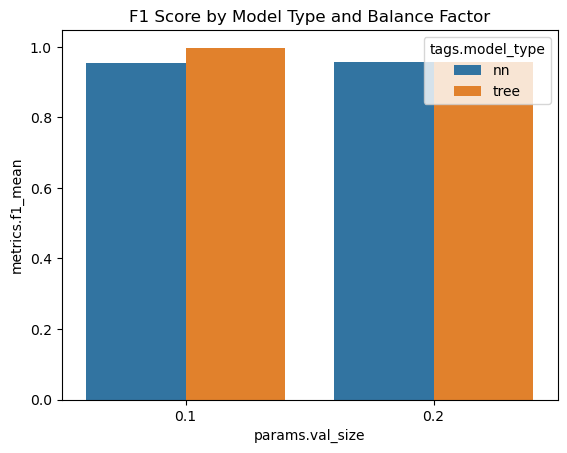

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df_summary

sns.barplot(
    data=df,
    x="params.val_size",
    y="metrics.f1_mean",
    hue="tags.model_type"
)
plt.title("F1 Score by Model Type and Balance Factor")
plt.show()


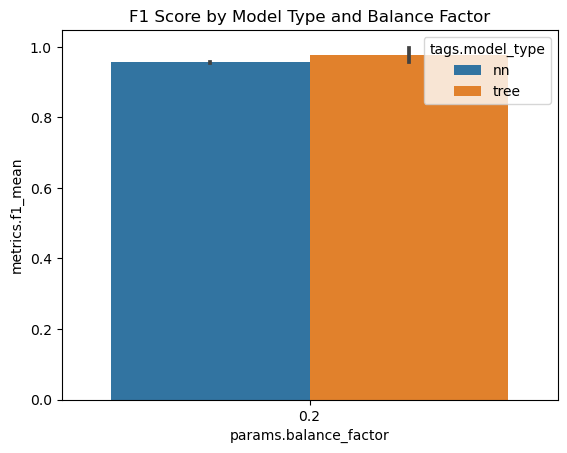

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df_summary

sns.barplot(
    data=df,
    x="params.balance_factor",
    y="metrics.f1_mean",
    hue="tags.model_type"
)
plt.title("F1 Score by Model Type and Balance Factor")
plt.show()


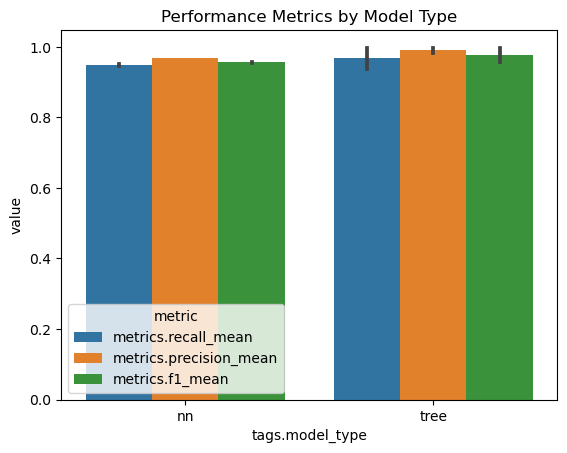

In [59]:
melted = df.melt(
    id_vars=["tags.model_type", "params.val_size", "params.balance_factor"],
    value_vars=["metrics.recall_mean", "metrics.precision_mean", "metrics.f1_mean"],
    var_name="metric",
    value_name="value"
)

sns.barplot(
    data=melted,
    x="tags.model_type",
    y="value",
    hue="metric"
)
plt.title("Performance Metrics by Model Type")
plt.show()


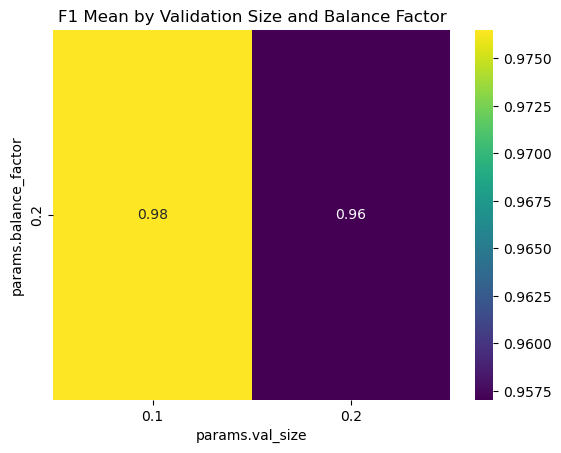

In [60]:
pivot = df.pivot_table(
    index="params.balance_factor",
    columns="params.val_size",
    values="metrics.f1_mean"
)
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("F1 Mean by Validation Size and Balance Factor")
plt.show()


In [61]:
top3 = (
    df.sort_values(by="metrics.f1_mean", ascending=False)
      .head(3)
      .reset_index(drop=True)
)
print(top3)


  tags.data_version tags.model_type params.val_size params.balance_factor  \
0                v1            tree             0.1                   0.2   
1                v1              nn             0.2                   0.2   
2                v1            tree             0.2                   0.2   

   metrics.recall_mean  metrics.accuracy_mean  metrics.f1_mean  \
0             0.997930               0.997930         0.997933   
1             0.952105               0.952105         0.957513   
2             0.936421               0.936421         0.956559   

   metrics.precision_mean  
0                0.997951  
1                0.967793  
2                0.981838  


In [ ]:
# my hyperpaarms?????????????

## with runs directly

In [20]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
experiment = client.get_experiment_by_name('nn_experiment')


filter_str = f"run_name = 'Tuning' AND tags.data_version = 'v1'"


# Search runs
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string=filter_str,
)



In [21]:
runs

[<Run: data=<RunData: metrics={'accuracy': 0.9577000194036608,
  'f1': 0.9626601972689025,
  'precision': 0.9709623624781679,
  'recall': 0.9577000194036608}, params={'balance_factor': '0.2',
  'train_shape': '(150434, 78)',
  'val_shape': '(15461, 78)',
  'val_size': '0.2'}, tags={'data_version': 'v1',
  'mlflow.runName': 'Tuning',
  'mlflow.source.git.commit': 'db6fa718a8577f288280cc2d37aba95fb7c2bfc8',
  'mlflow.source.name': '/home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security/scripts/tuning.py',
  'mlflow.source.type': 'LOCAL',
  'mlflow.user': 'marcos',
  'model_type': 'nn'}>, info=<RunInfo: artifact_uri='/home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security/mlruns/1/0950e7cdd0a747c4bcdf85f8e0e9f802/artifacts', end_time=1761848244093, experiment_id='1', lifecycle_stage='active', run_id='0950e7cdd0a747c4bcdf85f8e0e9f802', run_name='Tuning', start_time=1761848202599, status='FINISHED', user_id='marcos'>, inputs=<RunInputs: dataset_inputs=[], model_inputs=[]>, outputs=No

In [22]:
import pandas as pd

# Search runs
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string=filter_str,
)

# Convert to a list of dictionaries
runs_data = []
for run in runs:
    run_dict = run.to_dictionary()  # contains params, metrics, tags, etc.
    runs_data.append(run_dict)

# Convert to DataFrame
df = pd.DataFrame(runs_data)

# Optional: flatten nested dictionaries (params, metrics, tags)
df = pd.json_normalize(df.to_dict(orient="records"))

df.head()


,info.artifact_uri,info.end_time,info.experiment_id,info.lifecycle_stage,info.run_id,info.run_name,info.start_time,info.status,info.user_id,data.metrics.accuracy,...,data.params.val_shape,data.tags.mlflow.user,data.tags.mlflow.source.name,data.tags.mlflow.source.type,data.tags.mlflow.source.git.commit,data.tags.mlflow.runName,data.tags.model_type,data.tags.data_version,inputs.model_inputs,inputs.dataset_inputs
0,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,1761848244093,1,active,0950e7cdd0a747c4bcdf85f8e0e9f802,Tuning,1761848202599,FINISHED,marcos,0.957700,...,"(15461, 78)",marcos,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,LOCAL,db6fa718a8577f288280cc2d37aba95fb7c2bfc8,Tuning,nn,v1,[],[]
1,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,1761845527855,1,active,80bcffc9868a4e078161b4a8975ff448,Tuning,1761845487588,FINISHED,marcos,0.964039,...,"(15461, 78)",marcos,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,LOCAL,db6fa718a8577f288280cc2d37aba95fb7c2bfc8,Tuning,nn,v1,[],[]
2,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,1761778522453,1,active,c68659947c2941a1b46b760a2cda1cee,Tuning,1761778506242,FINISHED,marcos,0.984671,...,"(15461, 78)",marcos,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,LOCAL,5ac0483257be274119e1cbe9d61ae4fd92be9c7b,Tuning,tree,v1,[],[]
3,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,1761778516625,1,active,343630f8619942569ac991a1b5183104,Tuning,1761778501772,FINISHED,marcos,0.997930,...,"(7731, 78)",marcos,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,LOCAL,5ac0483257be274119e1cbe9d61ae4fd92be9c7b,Tuning,tree,v1,[],[]
4,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,1761778501380,1,active,d1874cd1f3f04f148a16145d083dd3f7,Tuning,1761778459736,FINISHED,marcos,0.948063,...,"(15461, 78)",marcos,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,LOCAL,5ac0483257be274119e1cbe9d61ae4fd92be9c7b,Tuning,nn,v1,[],[]


df.columns

In [23]:
df.columns

Index(['info.artifact_uri', 'info.end_time', 'info.experiment_id',
       'info.lifecycle_stage', 'info.run_id', 'info.run_name',
       'info.start_time', 'info.status', 'info.user_id',
       'data.metrics.accuracy', 'data.metrics.precision',
       'data.metrics.recall', 'data.metrics.f1', 'data.params.balance_factor',
       'data.params.val_size', 'data.params.train_shape',
       'data.params.val_shape', 'data.tags.mlflow.user',
       'data.tags.mlflow.source.name', 'data.tags.mlflow.source.type',
       'data.tags.mlflow.source.git.commit', 'data.tags.mlflow.runName',
       'data.tags.model_type', 'data.tags.data_version', 'inputs.model_inputs',
       'inputs.dataset_inputs'],
      dtype='object')

In [24]:
df['data.tags.model_type']

0      nn
1      nn
2    tree
3    tree
4      nn
5      nn
6      nn
7    tree
Name: data.tags.model_type, dtype: object